In [ ]:
from pathlib import Path

import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18
import torchvision.transforms as transforms

from membership_dataset import MembershipDataset

In [ ]:
BASE = Path().resolve()
PUB_PATH = BASE / "pub.pt"
PRIV_PATH = BASE / "priv.pt"
MODEL_PATH = BASE / "model.pt"
OUTPUT_CSV = BASE / "submission.csv"

In [3]:
model = resnet18(weights=None)
model.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # small images
model.maxpool = torch.nn.Identity()   # remove maxpool
model.fc = torch.nn.Linear(512, 9)   # 9 classes
model.load_state_dict(torch.load("model.pt", map_location="cpu"))
model.eval()                          # critical for inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [4]:
MEAN = [0.7406, 0.5331, 0.7059]   # per-channel mean used during training
STD = [0.1491, 0.1864, 0.1301]    # per-channel std used during training

transform = transforms.Compose([
    transforms.Resize(32),                     # resize to match training resolution
    transforms.Normalize(mean=MEAN, std=STD),  # (pixel - mean) / std per channel
])

In [ ]:
pub_ds = torch.load(PUB_PATH, weights_only=False)
pub_ds.transform = transform    # attach normalization after loading
loader = DataLoader(pub_ds, batch_size=64, shuffle=False)

In [ ]:
all_ids = []
all_scores = []
all_labels = []
all_memberships = []
all_preds = []

with torch.no_grad():
    for id_, imgs, labels, membership in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        scores = probs.max(dim=1).values.cpu().numpy()  # max prob as membership score
        predicted_label = probs.argmax(dim=1).cpu().numpy() # predicted label

        all_ids.extend(id_.tolist())
        all_scores.extend(scores.tolist())
        all_labels.extend(labels.tolist())
        all_memberships.extend(membership.tolist())
        all_preds.extend(predicted_label.tolist())

In [ ]:
df = pd.DataFrame({
    "id": all_ids,
    "label": all_labels,
    "membership": all_memberships,
    "score": all_scores,
    "predicted_label": all_preds,
})

df

,id,label,membership,score,predicted_label
0,72212,8,1,0.938240,8
1,21370,2,0,0.958307,2
2,52004,0,1,0.942664,0
3,29848,8,0,0.944517,8
4,45154,2,0,0.953976,2
...,...,...,...,...,...
13995,42581,8,0,0.940844,8
13996,12732,0,0,0.954298,0
13997,41211,1,1,0.953219,1
13998,16842,2,0,0.963413,2


In [ ]:
# df.to_csv("max_confidence_test_pub_data", index=False)

In [ ]:
# df = pd.read_csv("max_confidence_test_pub_data")
# df

,id,label,membership,score,predicted_label
0,72212,8,1,0.938240,8
1,21370,2,0,0.958307,2
2,52004,0,1,0.942664,0
3,29848,8,0,0.944517,8
4,45154,2,0,0.953976,2
...,...,...,...,...,...
13995,42581,8,0,0.940844,8
13996,12732,0,0,0.954298,0
13997,41211,1,1,0.953219,1
13998,16842,2,0,0.963413,2


In [9]:
df["label"].value_counts()

label
8    2040
5    1795
3    1581
1    1548
2    1546
0    1515
7    1405
4    1348
6    1222
Name: count, dtype: int64

In [10]:
df["predicted_label"].value_counts()

predicted_label
8    2042
5    1797
3    1577
1    1549
2    1540
0    1517
7    1408
4    1350
6    1220
Name: count, dtype: int64

In [11]:
df["score"].describe()

count    14000.000000
mean         0.946463
std          0.045072
min          0.320213
25%          0.946308
50%          0.953311
75%          0.960027
max          0.990566
Name: score, dtype: float64

In [13]:
df[df["membership"] == 0].describe()

,id,label,membership,score,predicted_label
count,7000.000000,7000.000000,7000.0,7000.000000,7000.000000
mean,53892.868286,4.096000,0.0,0.944828,4.098000
std,30953.694957,2.640142,0.0,0.051249,2.641259
min,0.000000,0.000000,0.0,0.320213,0.000000
25%,27270.750000,2.000000,0.0,0.946247,2.000000
50%,53846.500000,4.000000,0.0,0.953292,4.000000
75%,80699.000000,6.000000,0.0,0.959990,6.000000
max,107153.000000,8.000000,0.0,0.989708,8.000000


In [ ]:
df[df["membership"] == 1].describe()

,id,label,membership,score,predicted_label
count,7000.000000,7000.000000,7000.0,7000.000000,7000.000000
mean,53223.669286,4.080714,1.0,0.948098,4.081571
std,31085.083470,2.646194,0.0,0.037833,2.646762
min,4.000000,0.000000,1.0,0.364477,0.000000
25%,26123.250000,2.000000,1.0,0.946355,2.000000
50%,53687.000000,4.000000,1.0,0.953341,4.000000
75%,79974.750000,6.000000,1.0,0.960070,6.000000
max,107176.000000,8.000000,1.0,0.990566,8.000000


In [19]:
df[df["membership"] == 1]["label"].value_counts()

label
8    1045
5     898
3     798
2     796
1     774
0     754
7     665
4     660
6     610
Name: count, dtype: int64

<Axes: xlabel='label'>

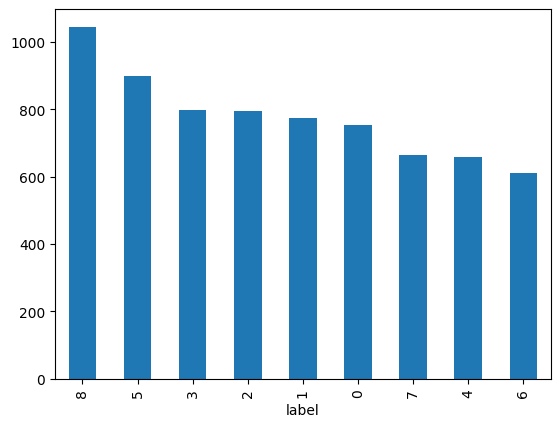

In [23]:
import matplotlib.pyplot as plt
df[df["membership"] == 1]["label"].value_counts().plot(kind="bar")

In [16]:
df[df["membership"] == 0]["label"].value_counts()

label
8    995
5    897
3    783
1    774
0    761
2    750
7    740
4    688
6    612
Name: count, dtype: int64

<Axes: xlabel='label'>

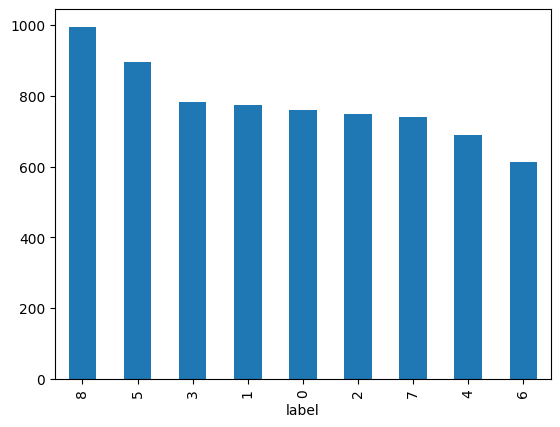

In [24]:
df[df["membership"] == 0]["label"].value_counts().plot(kind="bar")

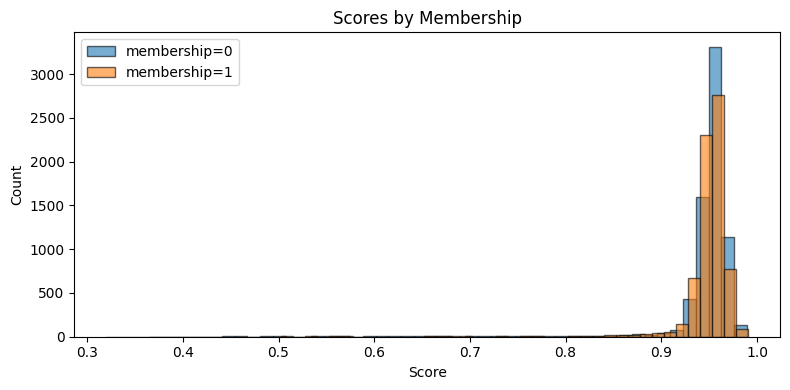

In [30]:
plt.figure(figsize=(8, 4))
for m, group in df.groupby("membership"):
    plt.hist(group["score"], bins=50, alpha=0.6, label=f"membership={m}", edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Scores by Membership")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# OBSERVATION:
# Both members and non-members have high confidence scores. The true labels are almost uniformly distributed. 
# Hence using just the confidence score is a very poor indicator of membership.